<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Jiale Chen
- Nombre de alumno 2:

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [23]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly

Resolved 146 packages in 19ms
Checked 139 packages in 51ms


In [24]:
import warnings

import nltk
import numpy as np
import optuna
import pandas as pd
import plotly.express as px
import shap
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
)
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [25]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [26]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [27]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [28]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [29]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

> **Respuesta:**

1- Un baseline en Machine Learning es un modelo de referencia simple que se utiliza para establecer un nivel mínimo de rendimiento. Sirve como punto de comparación para evaluar si modelos más complejos realmente están aprendiendo patrones útiles de los datos.

Establecer un baseline permite interpretar mejor los resultados obtenidos y verificar que las mejoras de modelos más avanzados sean reales. Si un modelo complejo no supera al baseline, es una señal de que podría existir algún problema en los datos, el preprocesamiento o la configuración del modelo.

2- Utilizamos un `DummyClassifier` como baseline porque implementa estrategias simples que no aprenden de los datos, como predecir siempre la clase más frecuente o predecir aleatoriamente. Esto permite establecer un rendimiento mínimo de referencia para comparar modelos más avanzados.

Si un modelo "real" no supera al `DummyClassifier`, significa que no está aprovechando la información disponible en los datos. Esto puede indicar problemas en el preprocesamiento, la selección de características, la configuración del modelo o una baja capacidad predictiva de los datos.

In [30]:
# Escribe aquí la respuesta


---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [31]:
#### Código aquí ####

# Separar variables predictoras y objetivo
X = df_comics.drop(columns=["alignment"])
y = df_comics["alignment"]

# División 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Pipeline con preprocesamiento y árbol de decisión
tree_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)

# Entrenar y predecir
tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)

# Reporte de métricas
print("DecisionTreeClassifier")
print(classification_report(y_test, y_pred_tree))

# Pipeline baseline
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    ]
)

# Entrenar y predecir
dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_test)

# Reporte de métricas
print("DummyClassifier")
print(classification_report(y_test, y_pred_dummy))

DecisionTreeClassifier
              precision    recall  f1-score   support

         Bad       0.41      0.43      0.42        86
        Good       0.66      0.61      0.64       148
     Neutral       0.10      0.13      0.11        23

    accuracy                           0.51       257
   macro avg       0.39      0.39      0.39       257
weighted avg       0.53      0.51      0.52       257

DummyClassifier
              precision    recall  f1-score   support

         Bad       0.32      0.34      0.33        86
        Good       0.58      0.56      0.57       148
     Neutral       0.12      0.13      0.12        23

    accuracy                           0.45       257
   macro avg       0.34      0.34      0.34       257
weighted avg       0.46      0.45      0.45       257



### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> **Respuesta:**

0- Sí, el `DecisionTreeClassifier` supera al `DummyClassifier` en todas las métricas principales. Obtiene una exactitud de 0.51 frente a 0.45 y un F1-score macro de 0.39 frente a 0.34.

Esto indica que el árbol de decisión ha logrado aprender patrones útiles a partir de las características del dataset, tanto del texto como de los atributos numéricos. Como su desempeño es mejor que el de un modelo que no aprende de los datos, podemos concluir que las variables utilizadas contienen información relevante para predecir la alineación de los personajes. Sin embargo, los resultados aún son mejorables, especialmente en la clase `Neutral`, por lo que modelos más avanzados podrían obtener un rendimiento superior.

1- El accuracy puede ser una métrica engañosa cuando las clases están desbalanceadas, ya que un modelo puede obtener una alta exactitud simplemente prediciendo con frecuencia la clase mayoritaria. En ese caso, el resultado global parece bueno, pero el modelo puede estar clasificando incorrectamente muchas observaciones de las clases menos representadas.

Una métrica más apropiada es el **F1-score macro**, ya que calcula el F1-score para cada clase por separado y luego obtiene el promedio, otorgando la misma importancia a todas las clases independientemente de su frecuencia. Esto permite evaluar de manera más justa el rendimiento del modelo cuando existe desbalance entre las clases.

2- El parámetro `stratify` se utiliza para mantener la misma proporción de clases en los conjuntos de entrenamiento y prueba que existe en el dataset original. Esto es especialmente importante cuando las clases están desbalanceadas.

Al usar `stratify`, evitamos que alguna clase quede sobre representada o subrepresentada en alguno de los conjuntos debido al azar de la partición. Sin esta opción, podría ocurrir que una clase minoritaria tenga muy pocos ejemplos en el conjunto de prueba o incluso desaparezca por completo, generando una evaluación poco confiable del modelo. Por lo tanto, `stratify` asegura que tanto el entrenamiento como la evaluación se realicen sobre muestras representativas de la distribución real de las clases.

3- Sí, el `DecisionTreeClassifier` es mejor que su versión aleatoria representada por el `DummyClassifier`. Mientras el árbol de decisión obtiene un accuracy de 0.51 y un F1-score macro de 0.39, el modelo dummy alcanza 0.45 y 0.34 respectivamente.

Esto indica que el clasificador está aprendiendo patrones presentes en los datos y utilizando esa información para realizar mejores predicciones que una estrategia basada únicamente en el azar o en la distribución de las clases. Por lo tanto, podemos avanzar con confianza, ya que el modelo está clasificando mejor que si asignáramos las clases aleatoriamente, como al lanzar un dado de tres caras. Sin embargo, el margen de mejora aún es considerable, por lo que tiene sentido explorar modelos de ensamblaje y técnicas de optimización para obtener un rendimiento superior.

In [32]:
# Escribe aquí la respuesta

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?

> **Respuesta:**


Bagging (*Bootstrap Aggregating*) es una técnica de ensamblaje que busca mejorar el rendimiento y la estabilidad de un modelo combinando las predicciones de varios modelos entrenados sobre diferentes muestras de los datos. En lugar de depender de un único modelo, se construye un conjunto de modelos que trabajan en conjunto para producir una predicción más robusta.

El proceso comienza generando múltiples subconjuntos de entrenamiento a partir del dataset original mediante muestreo aleatorio con reemplazo, conocido como *bootstrap*. Esto significa que cada subconjunto contiene una selección aleatoria de instancias donde algunas pueden repetirse varias veces y otras pueden no aparecer. Aunque cada subconjunto suele tener un tamaño similar al dataset original, ninguno es exactamente igual a él.

Posteriormente, se entrena un modelo independiente sobre cada uno de estos subconjuntos. Generalmente se utilizan modelos del mismo tipo, como árboles de decisión. Debido a que cada modelo recibe datos ligeramente distintos, cada uno aprende patrones diferentes. Además, los modelos se entrenan de manera completamente independiente, sin intercambiar información durante el proceso de aprendizaje.

Finalmente, las predicciones de todos los modelos se combinan para obtener una respuesta final. En problemas de clasificación, como el de este laboratorio, normalmente se utiliza votación mayoritaria: cada modelo emite una predicción y la clase con más votos se considera la predicción final. Gracias a esta agregación, Bagging reduce la varianza de los modelos individuales y suele producir resultados más precisos y estables.

In [33]:
# Escribe aquí la respuesta

---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [34]:
#### Código aquí ####

# Pipeline con preprocesamiento y Random Forest
rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Entrenar modelo
rf_pipeline.fit(X_train, y_train)

# Predecir sobre test
y_pred_rf = rf_pipeline.predict(X_test)

# Reporte de métricas
print("RandomForestClassifier")
print(classification_report(y_test, y_pred_rf))

RandomForestClassifier
              precision    recall  f1-score   support

         Bad       0.60      0.30      0.40        86
        Good       0.63      0.91      0.75       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.63       257
   macro avg       0.41      0.40      0.38       257
weighted avg       0.57      0.63      0.57       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:**

Sí, el `RandomForestClassifier` mejoró respecto al baseline. Mientras que el `DummyClassifier` obtuvo un accuracy de 0.45 y un F1-score macro de 0.34, el Random Forest alcanzó un accuracy de 0.63 y un F1-score macro de 0.38. Esto indica que el modelo está aprendiendo patrones relevantes de los datos y logra realizar predicciones considerablemente mejores que una estrategia aleatoria basada en la distribución de clases.

Al analizar el `classification_report`, se observa que el modelo obtiene muy buenos resultados para la clase `Good`, alcanzando un recall de 0.91 y un F1-score de 0.75. Sin embargo, su desempeño en la clase `Bad` es más moderado y no logra identificar correctamente ningún caso de la clase `Neutral`, obteniendo valores de precisión, recall y F1-score iguales a 0. Esto sugiere que el modelo tiende a favorecer las clases más frecuentes y tiene dificultades para reconocer la clase minoritaria.

La mejora respecto al árbol de decisión individual se debe a las características propias de Bagging. Random Forest entrena múltiples árboles sobre diferentes muestras bootstrap del conjunto de entrenamiento y luego combina sus predicciones mediante votación. Esta estrategia reduce la varianza de los árboles individuales y genera predicciones más estables y robustas. No obstante, aunque mejora el rendimiento global, el desbalance de clases sigue afectando la capacidad del modelo para clasificar correctamente la clase `Neutral`.

In [35]:
# Escribe aquí la respuesta

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

> **Respuesta:**

Boosting es una técnica de ensamblaje que construye varios modelos simples de manera secuencial con el objetivo de corregir progresivamente los errores cometidos por los modelos anteriores. A diferencia de Bagging, donde todos los modelos se entrenan de forma independiente y en paralelo, en Boosting cada nuevo modelo depende de los resultados obtenidos por los modelos previos. Esto hace que el aprendizaje sea un proceso iterativo en el que cada modelo intenta mejorar el desempeño global del conjunto.

Durante el entrenamiento, cada nuevo modelo se enfoca especialmente en las observaciones que fueron clasificadas incorrectamente por los modelos anteriores. Para lograr esto, el algoritmo utiliza información sobre los errores o residuos generados por el modelo previo y asigna mayor importancia a las instancias más difíciles de predecir. De esta manera, el conjunto de modelos va corrigiendo gradualmente sus errores y aprendiendo patrones cada vez más complejos.

Una vez entrenados todos los modelos, las predicciones se combinan para generar la respuesta final. A diferencia de Bagging, donde normalmente se utiliza una votación simple, en Boosting las predicciones se combinan de forma ponderada. Los modelos que contribuyen con mejores correcciones suelen tener un peso mayor en la predicción final, permitiendo que el ensamblaje aproveche mejor la información aprendida durante cada etapa del entrenamiento.

XGBoost y LightGBM son implementaciones modernas de Boosting basadas en árboles de decisión. XGBoost se caracteriza por incorporar técnicas de regularización y optimizaciones que mejoran la precisión y reducen el sobreajuste. LightGBM, en cambio, está diseñado para ser más rápido y eficiente en memoria, utilizando estrategias de crecimiento de árboles y manejo de datos que permiten entrenar modelos de gran tamaño en menos tiempo.

Respecto a las etiquetas, XGBoost requiere que las clases estén representadas mediante valores numéricos porque su implementación interna trabaja directamente con códigos enteros para calcular la función objetivo. Por esta razón, en problemas de clasificación es necesario aplicar previamente un `LabelEncoder`. LightGBM, por otro lado, puede recibir etiquetas en formato string y realizar internamente la conversión necesaria, simplificando el flujo de trabajo para el usuario.

In [36]:
# Escribe aquí la respuesta

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [37]:
#### Código aquí ####

# Codificar etiquetas para XGBoost
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Pipeline con XGBoost
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="mlogloss",
                verbosity=0,
            ),
        ),
    ]
)

# Entrenar con etiquetas codificadas
xgb_pipeline.fit(X_train, y_train_encoded)

# Predecir y decodificar etiquetas
y_pred_xgb_encoded = xgb_pipeline.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

# Reporte de métricas
print("XGBClassifier")
print(classification_report(y_test, y_pred_xgb))

XGBClassifier
              precision    recall  f1-score   support

         Bad       0.55      0.42      0.47        86
        Good       0.68      0.84      0.75       148
     Neutral       0.33      0.09      0.14        23

    accuracy                           0.63       257
   macro avg       0.52      0.45      0.45       257
weighted avg       0.60      0.63      0.60       257



In [38]:
# Pipeline con LightGBM
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            LGBMClassifier(
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        ),
    ]
)

# Entrenar con etiquetas originales
lgbm_pipeline.fit(X_train, y_train)

# Predecir
y_pred_lgbm = lgbm_pipeline.predict(X_test)

# Reporte de métricas
print("LGBMClassifier")
print(classification_report(y_test, y_pred_lgbm))

LGBMClassifier
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

> **Respuesta:**

Tanto XGBoost como LightGBM mejoran claramente respecto al baseline (`DummyClassifier`), que obtuvo un F1-score macro de 0.34. Ambos modelos alcanzan un F1-score macro de aproximadamente 0.45, lo que indica que son capaces de aprender patrones relevantes de los datos y realizar predicciones más precisas que una estrategia aleatoria.

Si se compara específicamente el F1-score macro, ambos modelos obtienen un valor muy similar (0.45). Sin embargo, LightGBM logra una mayor exactitud global (0.68 frente a 0.63 de XGBoost) y mejores resultados en las clases `Good` y `Bad`. Por otro lado, XGBoost consigue identificar algunos ejemplos de la clase `Neutral` (F1-score de 0.14), mientras que LightGBM no logra clasificar correctamente ningún caso de esta clase.

Las similitudes en rendimiento se deben a que ambos algoritmos utilizan Boosting y construyen secuencialmente árboles que corrigen los errores de los modelos anteriores. No obstante, las diferencias observadas pueden atribuirse a la forma en que cada implementación construye los árboles y optimiza el entrenamiento. LightGBM está diseñado para ser más eficiente y suele encontrar soluciones que favorecen el rendimiento global, mientras que XGBoost incorpora estrategias de regularización más conservadoras que pueden ayudar a capturar mejor algunas observaciones difíciles, como ocurrió con la clase `Neutral`.

En general, LightGBM presenta el mejor desempeño global gracias a su mayor accuracy y F1-score en las clases mayoritarias, mientras que XGBoost muestra una ligera ventaja al menos detectando algunos casos de la clase minoritaria. Esto sugiere que el desbalance de clases sigue siendo un desafío importante para ambos modelos.

In [39]:
# Escribe aquí la respuesta

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**

Stacking es una técnica de ensamblaje que combina varios modelos diferentes con el objetivo de aprovechar las fortalezas de cada uno. En lugar de seleccionar un único modelo como mejor candidato, Stacking utiliza las predicciones de varios modelos base para entrenar un modelo adicional, llamado meta-modelo, encargado de producir la predicción final.

Los modelos base son los primeros en entrenarse sobre los datos originales y generan predicciones que posteriormente se utilizan como nuevas características. Para evitar que el meta-modelo aprenda a partir de predicciones demasiado optimistas, estas predicciones se obtienen mediante validación cruzada interna. De esta forma, cada observación es predicha por modelos que no fueron entrenados con ella, reduciendo el riesgo de sobreajuste y proporcionando información más realista para el siguiente nivel del ensamblaje.

El meta-modelo recibe como entrada las predicciones generadas por todos los modelos base y aprende cómo combinarlas de la mejor manera posible. Mientras que los modelos base intentan aprender patrones directamente desde las variables originales del problema, el meta-modelo aprende cuáles modelos son más confiables en distintas situaciones y cómo ponderar sus predicciones para obtener un mejor resultado final.

La principal ventaja de Stacking es que puede superar el rendimiento de cualquier modelo individual. Esto ocurre porque aprovecha la diversidad entre los modelos base: algunos pueden cometer errores distintos o capturar patrones diferentes de los datos. El meta-modelo aprende a combinar estas perspectivas complementarias, reduciendo errores individuales y generando predicciones más robustas y precisas que las de un único modelo por separado.

In [40]:
# Escribe aquí la respuesta

---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [41]:
X_train[X_train.isna().any(axis=1)]

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
1120,Sai,NaN,Sai Yamanaka,6,Sai Yamanaka was an Anbu from Root. He is adde...,NaN,70,30,60,50,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
1236,Steve Trevor,Steve Trevor,Stephen Rockwell Trevor,8,"Steve Trevor is a commercial pilot, a retired ...",NaN,95,10,15,10,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
486,Flash III,Wally West,Wallace Rudolph West,10,Wally West was born to Rudolph and Mary West ...,While all speedsters are powered by the for...,80,10,100,60,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0
114,Bane,NaN,NaN,9,"Born to serve the life sentence of his father,...",Bane's use of the Supersteroid Venom allowed h...,85,75,50,70,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
623,Hush,Thomas Elliot,Thomas Elliot,8,"Born a child of wealth and privilege, young Th...",,95,10,25,40,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,Lucius Malfoy,NaN,NaN,14,We know very little about Lucius' past. He fir...,NaN,90,10,20,20,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1222,Star Sapphire,Carol Ferris,NaN,14,Carol Ferris is the boss and occasional love i...,Energy Projection The jewel can be used to fi...,90,55,75,70,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
54,Angel Dust,Christina,Christina,4,Christine was raised in the suburbs of Chica...,Christine can elevate her adrenaline levels ...,70,55,25,40,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
109,Azrael (Gotham),Theo Galavan,Theodore Galavan,9,"Theodore ""Theo"" Galavan was the mayor of Gotha...",Theo was artificially reanimated back to life...,95,40,55,75,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
from sklearn.linear_model import SGDClassifier

base_models = [
    ("logistic_regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("multinomial_nb", MultinomialNB()),
    ("sgd_classifier", SGDClassifier(loss="log_loss", random_state=RANDOM_STATE)),
]

meta_model = DecisionTreeClassifier(random_state=RANDOM_STATE)

stacking_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            StackingClassifier(
                estimators=base_models,
                final_estimator=meta_model,
                cv=3,
                n_jobs=-1,
            ),
        ),
    ]
)

stacking_pipeline.fit(X_train, y_train)
y_pred_stacking = stacking_pipeline.predict(X_test)

print("StackingClassifier")
print(classification_report(y_test, y_pred_stacking))

StackingClassifier
              precision    recall  f1-score   support

         Bad       0.46      0.52      0.49        86
        Good       0.71      0.66      0.69       148
     Neutral       0.14      0.13      0.13        23

    accuracy                           0.57       257
   macro avg       0.44      0.44      0.44       257
weighted avg       0.58      0.57      0.57       257



### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**

Se eligieron como modelos base `LogisticRegression`, `MultinomialNB` y `SGDClassifier` porque representan enfoques simples pero distintos de clasificación. `LogisticRegression` aporta un modelo lineal estable, útil para datos de alta dimensionalidad como Bag of Words. `MultinomialNB` es especialmente adecuado para conteos de palabras, por lo que se ajusta bien al componente textual del problema. `SGDClassifier`, usando `loss="log_loss"`, también actúa como un clasificador lineal eficiente y puede aprender patrones en espacios con muchas variables.

Como meta-modelo se utilizó `DecisionTreeClassifier`, ya que permite combinar las salidas de los modelos base de forma flexible, sin asumir una relación lineal entre ellas. Además, en este caso resultó más estable que usar modelos lineales como meta-modelo.

El Stacking obtuvo un F1-score macro de 0.44 y un accuracy de 0.57. Esto mejora respecto al baseline, al árbol de decisión inicial y al Random Forest en F1-macro, pero no supera claramente a XGBoost ni LightGBM, que alcanzaron aproximadamente 0.45 de F1-macro.

Este resultado puede atribuirse a que Stacking aprovecha la diversidad entre modelos base, combinando sus errores y aciertos mediante el meta-modelo. Sin embargo, como los modelos base usados son clasificadores simples y todos siguen teniendo dificultades con la clase minoritaria `Neutral`, el meta-modelo no cuenta con suficiente información para mejorar mucho más el rendimiento final.

In [ ]:
# Escribe aquí la respuesta

---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

> **Respuesta:**

1- Los hiperparámetros son configuraciones definidas antes del entrenamiento que controlan cómo aprende el modelo, por ejemplo, la profundidad de un árbol o la tasa de aprendizaje. Estos valores no se aprenden a partir de los datos.

En cambio, los parámetros son los valores que el modelo aprende automáticamente durante el entrenamiento, como los coeficientes de una regresión o las reglas de división de un árbol. En resumen, los hiperparámetros se configuran antes de entrenar y los parámetros se aprenden durante el entrenamiento.

2- Optimizar los hiperparámetros es importante porque influye directamente en el rendimiento del modelo. Una buena configuración puede mejorar la capacidad de generalización y obtener predicciones más precisas.

Utilizar los valores por defecto puede producir modelos subóptimos, ya sea por sobreajuste (*overfitting*), cuando el modelo aprende demasiado los datos de entrenamiento, o por subajuste (*underfitting*), cuando no logra capturar los patrones relevantes. Por ello, ajustar los hiperparámetros permite encontrar una configuración más adecuada para el problema específico.

3- `GridSearchCV` es una técnica de búsqueda exhaustiva de hiperparámetros que prueba todas las combinaciones posibles definidas en una grilla de valores. Para cada combinación, entrena y evalúa el modelo mediante validación cruzada, seleccionando finalmente aquella que obtiene el mejor rendimiento según una métrica determinada.

Su principal limitación es que el costo computacional crece rápidamente cuando aumenta la cantidad de hiperparámetros o de valores a evaluar. Como debe probar todas las combinaciones posibles, puede volverse muy lento e ineficiente en espacios de búsqueda grandes.

4- Cada *trial* se evalúa mediante validación cruzada porque permite estimar de forma más confiable el rendimiento del modelo utilizando únicamente los datos de entrenamiento. De esta manera, los hiperparámetros se seleccionan sin utilizar información del conjunto de test, que debe reservarse para la evaluación final.

Si se utilizara el conjunto de test para seleccionar hiperparámetros, se produciría una fuga de información (*data leakage*). En ese caso, los hiperparámetros quedarían ajustados específicamente al conjunto de test y la métrica obtenida sería demasiado optimista, dejando de representar el desempeño real del modelo sobre datos nuevos.

Una alternativa es separar parte de los datos de entrenamiento para crear un conjunto de validación. Los hiperparámetros se ajustarían usando ese conjunto y luego se evaluaría el modelo final sobre el test. Esto evita *data leakage*, ya que el modelo nunca observa los datos de test durante el proceso de selección de hiperparámetros, reservándolos exclusivamente para la evaluación final.

La principal ventaja de este enfoque es que requiere menos tiempo de cómputo que la validación cruzada. Sin embargo, la desventaja es que se dispone de menos datos para entrenar el modelo y la evaluación puede depender fuertemente de cómo se realizó la partición, generando estimaciones menos estables que las obtenidas con validación cruzada.

5- Los samplers inteligentes mejoran la limitación de `GridSearchCV` porque no prueban todas las combinaciones posibles de hiperparámetros. En lugar de hacer una búsqueda exhaustiva, utilizan los resultados de trials anteriores para decidir qué regiones del espacio de búsqueda parecen más prometedoras.

Un sampler como TPE puede ser más eficiente porque aprende qué valores de hiperparámetros tienden a producir mejores resultados y concentra la búsqueda en esas zonas. Así, puede encontrar buenas configuraciones con menos evaluaciones que `GridSearchCV`, reduciendo el costo computacional especialmente cuando el espacio de búsqueda es grande.

In [ ]:
# Escribe aquí la respuesta

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [ ]:
#### Código aquí #### (al parecer ya estaba implementado ...)

# def objective(trial):
#     params = {
#         "num_leaves": trial.suggest_int("num_leaves", 20, 200),
#         "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
#     }

#     model = Pipeline(
#         steps=[
#             ("preprocessing", preprocessing_transformer),
#             (
#                 "classifier",
#                 LGBMClassifier(
#                     **params,
#                     random_state=RANDOM_STATE,
#                     verbose=-1,
#                 ),
#             ),
#         ]
#     )

#     cv = StratifiedKFold(
#         n_splits=3,
#         shuffle=True,
#         random_state=RANDOM_STATE,
#     )

#     scores = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=cv,
#         scoring="f1_macro",
#         n_jobs=-1,
#     )

#     return scores.mean()

In [62]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [63]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 45. Best value: 0.460974: 100%|██████████| 50/50 [15:18<00:00, 18.36s/it]

Mejor F1-Macro: 0.4610

Mejores hiperparámetros:
  num_leaves: 162
  learning_rate: 0.24826634720393786
  max_depth: 5
  min_child_samples: 32
  subsample: 0.86156665512045
  colsample_bytree: 0.6076892262582765
  reg_alpha: 0.049830315821156726
  reg_lambda: 0.13497202734738575


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [64]:
#### Código aquí ####
# Historial de optimización
plot_optimization_history(study).show()

In [65]:
# Importancia de hiperparámetros
plot_param_importances(study).show()

In [66]:
# Coordenadas paralelas
plot_parallel_coordinate(study).show()

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [67]:
#### Código aquí ####

# Pipeline LightGBM con hiperparámetros optimizados
pipe_lgbm_opt = Pipeline(
    steps=[
        ("features", preprocessing_transformer),
        (
            "clf",
            LGBMClassifier(
                **study.best_params,
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        ),
    ]
)

# Entrenar modelo optimizado
pipe_lgbm_opt.fit(X_train, y_train)

# Predecir
y_pred_lgbm_opt = pipe_lgbm_opt.predict(X_test)

# F1-Macro modelo optimizado
f1_lgbm_opt = f1_score(y_test, y_pred_lgbm_opt, average="macro")

print(f"F1-Macro LightGBM optimizado: {f1_lgbm_opt:.4f}")

F1-Macro LightGBM optimizado: 0.5001


In [68]:
# Reporte de métricas
print("LGBMClassifier")
print(classification_report(y_test, y_pred_lgbm))
print("LightGBM optimizado")
print(classification_report(y_test, y_pred_lgbm_opt))

LGBMClassifier
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257

LightGBM optimizado
              precision    recall  f1-score   support

         Bad       0.59      0.55      0.57        86
        Good       0.71      0.84      0.77       148
     Neutral       1.00      0.09      0.16        23

    accuracy                           0.68       257
   macro avg       0.77      0.49      0.50       257
weighted avg       0.70      0.68      0.65       257



El modelo LightGBM optimizado logró mejorar el desempeño respecto a la versión con hiperparámetros por defecto. Aunque ambos modelos obtuvieron la misma exactitud (`accuracy = 0.68`), el F1-score macro aumentó de 0.45 a 0.50, lo que indica una mejora en el rendimiento promedio entre todas las clases.

La principal diferencia se observa en la clase `Neutral`. Mientras que el modelo original no logró identificar correctamente ningún ejemplo de esta clase (F1-score = 0.00), el modelo optimizado consiguió detectar algunos casos, alcanzando un F1-score de 0.16. Esto es especialmente relevante porque `Neutral` es la clase minoritaria del problema y suele ser la más difícil de clasificar.

Por otro lado, las métricas de las clases `Bad` y `Good` se mantuvieron muy similares entre ambos modelos, con una leve disminución en algunos indicadores. Sin embargo, esta pequeña pérdida se compensa con la mejora obtenida en la clase minoritaria, lo que explica el aumento del F1-score macro.

En conclusión, la optimización de hiperparámetros mediante Optuna permitió encontrar una configuración más equilibrada para el problema. Aunque no aumentó la exactitud global, sí mejoró la capacidad del modelo para reconocer clases menos representadas, lo que se refleja en un mejor F1-score macro y en una evaluación más favorable del desempeño general del clasificador.

### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

**Escribe aquí la respuesta:**

1- Según `plot_param_importances`, el hiperparámetro con mayor impacto fue `learning_rate`, con una importancia aproximada de 0.49, seguido por `reg_alpha` con cerca de 0.38. El resto de los hiperparámetros tuvo una contribución considerablemente menor.

Este resultado tiene sentido en algoritmos de Boosting como LightGBM. El `learning_rate` controla cuánto contribuye cada árbol nuevo a la predicción final y, por lo tanto, influye directamente en la velocidad y la forma en que el modelo aprende. Un valor muy alto puede provocar sobreajuste e incluso generar oscilaciones durante el proceso de optimización, ya que cada árbol realiza correcciones demasiado agresivas. Por el contrario, un valor muy bajo hace que el aprendizaje sea más gradual y estable, pero también que la convergencia sea más lenta, requiriendo generalmente un mayor número de árboles para alcanzar un buen rendimiento. Debido a este fuerte efecto sobre el proceso de entrenamiento, es esperable que sea uno de los hiperparámetros más influyentes.

También es razonable que `reg_alpha` aparezca entre los más importantes, ya que corresponde a la regularización L1 y ayuda a controlar la complejidad del modelo, reduciendo el sobreajuste y ayudando a extraer características relevantes para la clasificación. En cambio, parámetros como `subsample`, `reg_lambda` o `num_leaves` tuvieron un impacto mucho menor dentro del rango explorado por Optuna.

2- Los gráficos de Optuna entregan mucha más información que los logs de texto. Mientras que los logs permiten ver el resultado de cada trial y el mejor valor encontrado, las visualizaciones muestran cómo evoluciona el proceso de optimización y qué hiperparámetros tienen mayor influencia en el desempeño del modelo.

El gráfico `plot_optimization_history` permite observar que la mayor parte de las mejoras se obtuvo durante los primeros trials. Luego, el mejor F1-Macro se estabiliza cerca de 0.46 y los nuevos trials producen resultados similares, lo que sugiere que el sampler encontró rápidamente una región prometedora del espacio de búsqueda y posteriormente refinó la exploración alrededor de ella.

Por su parte, `plot_param_importances` mostró claramente que `learning_rate` y `reg_alpha` fueron los hiperparámetros más influyentes, algo que no es evidente al revisar únicamente los valores de los trials en texto.

Finalmente, `plot_parallel_coordinate` permite analizar simultáneamente las configuraciones asociadas a los mejores resultados. Al seleccionar las observaciones con mayor `Objective Value`, se observa que los mejores modelos tienden a concentrarse en valores altos de `num_leaves` (principalmente entre 100 y 200) y valores bajos o moderados de `min_child_samples` (aproximadamente entre 5 y 40). Asimismo, los mejores trials suelen utilizar valores altos de `subsample`, generalmente por sobre 0.8.

Respecto a `colsample_bytree`, las configuraciones con mejor desempeño se concentran principalmente entre 0.5 y 0.8, por lo que utilizar la totalidad de las características no parece ser necesario para obtener los mejores resultados. En cuanto a `learning_rate`, los mejores trials se ubican mayoritariamente en valores intermedios o altos dentro del rango explorado, mientras que los valores extremadamente bajos aparecen con menor frecuencia entre las configuraciones seleccionadas.

Por otro lado, `max_depth`, `reg_alpha` y `reg_lambda` presentan una dispersión relativamente alta incluso entre los mejores trials, lo que sugiere que existen múltiples combinaciones de complejidad y regularización capaces de alcanzar desempeños similares.

Esto sugiere que existen regiones específicas del espacio de búsqueda donde LightGBM obtiene un rendimiento consistentemente mejor. En particular, los mejores resultados parecen asociarse a árboles con muchas hojas, un muestreo alto de observaciones, un muestreo moderado de características y tasas de aprendizaje intermedias, más que a una configuración específica de regularización.

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [69]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparámetros, solo sobre scores numéricos
lgbm_interp = LGBMClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    verbose=-1,
)

# Entrenar modelo
lgbm_interp.fit(X_train_num, y_train)

,boosting_type,'gbdt'
,num_leaves,162
,max_depth,5
,learning_rate,0.24826634720393786
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,32


## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**

1- La Permutation Feature Importance (PFI) mide la importancia de una variable observando cuánto empeora el rendimiento del modelo cuando se rompe la relación entre esa variable y la variable objetivo. Para ello, se selecciona una característica y se permutan aleatoriamente sus valores entre las observaciones, manteniendo el resto de las variables sin cambios.

Luego de realizar la permutación, se vuelve a evaluar el modelo utilizando una métrica de desempeño, como F1-score o accuracy. Si el rendimiento disminuye significativamente, significa que la variable era importante para las predicciones. En cambio, si el desempeño cambia poco o nada, la característica aporta poca información al modelo.

Por lo tanto, la importancia de cada variable se estima comparando el rendimiento original del modelo con el rendimiento obtenido después de permutar sus valores.

2- PFI suele ser preferible a la importancia nativa de los árboles porque evalúa directamente cuánto contribuye cada variable al rendimiento real del modelo. En lugar de basarse en cómo se construyó el árbol, mide el efecto que tiene cada característica sobre las predicciones una vez que el modelo ya está entrenado.

La importancia nativa de los árboles presenta un sesgo hacia variables con muchos valores distintos o con más posibilidades de generar particiones. Como estas variables tienen más oportunidades de reducir la impureza durante el entrenamiento, pueden aparecer artificialmente como más importantes de lo que realmente son.

PFI evita este problema porque calcula la importancia observando la caída en el desempeño al permutar una variable, independientemente de cuántos valores distintos tenga o de cómo fue utilizada durante la construcción del modelo. Esto permite obtener una medida más objetiva y comparable entre características.

In [ ]:
# Escribe aquí la respuesta

---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [70]:
#### Código aquí ####
# Calcular Permutation Feature Importance
pfi = permutation_importance(
    lgbm_interp,
    X_test_num,
    y_test,
    n_repeats=30,
    scoring="f1_macro",
    random_state=RANDOM_STATE,
)

# DataFrame con resultados
pfi_df = pd.DataFrame(
    {
        "feature": X_test_num.columns,
        "importance_mean": pfi.importances_mean,
        "importance_std": pfi.importances_std,
    }
).sort_values("importance_mean", ascending=True)

# Gráfico horizontal
fig = px.bar(
    pfi_df,
    x="importance_mean",
    y="feature",
    orientation="h",
    error_x="importance_std",
    title="Permutation Feature Importance (PFI)",
    labels={
        "importance_mean": "Importancia promedio (Δ F1-Macro)",
        "feature": "Feature",
    },
)

fig.show()

### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**

Según el gráfico de PFI, la feature con mayor importancia es `strength_score`, ya que su permutación produce la mayor caída promedio en el F1-Macro. Le siguen `combat_score`, `speed_score` y `power_score`, mientras que `intelligence_score` aparece como la variable menos importante dentro de este modelo.

Este resultado tiene sentido en el contexto del problema, ya que muchos personajes de cómics suelen estar definidos por atributos relacionados con la fuerza, el poder o la capacidad de combate. Estas características pueden estar más asociadas a los patrones que el modelo utiliza para distinguir entre distintos tipos de alineación.

Sin embargo, resulta algo sorprendente que `intelligence_score` tenga una importancia tan baja. Intuitivamente, podría esperarse que personajes extremadamente inteligentes estuvieran asociados a ciertos comportamientos o alineaciones específicas. Una posible explicación es que la inteligencia, por sí sola, no sea suficiente para diferenciar héroes, villanos y personajes neutrales, ya que existen ejemplos de personajes muy inteligentes en todas las categorías.

También llama la atención que todas las importancias sean cercanas a cero e incluso negativas. Esto sugiere que, utilizando únicamente los seis atributos numéricos, ninguna variable tiene una influencia particularmente fuerte sobre las predicciones. Además, las barras de error son relativamente amplias, lo que indica una alta variabilidad en la estimación de importancia. Esto es consistente con la naturaleza del problema, donde gran parte de la información útil para clasificar la alineación probablemente se encuentra en el texto de la historia del personaje y no únicamente en sus atributos de habilidades.

In [ ]:
# Escribe aquí la respuesta

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**

1- Los valores SHAP miden cuánto contribuye cada característica a una predicción específica del modelo. Para cada observación, indican cuánto aumenta o disminuye la predicción respecto a un valor base, permitiendo entender por qué el modelo tomó una determinada decisión. Un valor SHAP positivo implica que la característica empuja la predicción hacia una clase determinada, mientras que un valor negativo indica que la aleja de ella.

La principal diferencia respecto a una medida global como PFI es que SHAP proporciona explicaciones locales, es decir, permite analizar la contribución de cada variable en una predicción individual. En cambio, PFI entrega una medida global de importancia basada en cuánto disminuye el rendimiento del modelo al permutar una característica. Por lo tanto, PFI responde qué variables son importantes en promedio para el modelo, mientras que SHAP explica cómo y cuánto influye cada variable en casos particulares.

2- El `base_value` en un `waterfall_plot` de SHAP representa la predicción promedio del modelo antes de considerar las características de una observación específica. Puede interpretarse como el punto de referencia o valor esperado a partir del cual comienza la explicación.

A partir de este valor base, cada característica aporta una contribución positiva o negativa reflejada en sus valores SHAP. Estas contribuciones van desplazando la predicción hacia arriba o hacia abajo hasta llegar a la predicción final del modelo para esa observación.

Por esta razón, el `base_value` es el punto de partida para interpretar una predicción individual: permite visualizar cómo cada variable modifica gradualmente la predicción promedio y entender cuáles características fueron responsables de que el modelo llegara a su resultado final.

3- `TreeExplainer` se utiliza para modelos basados en árboles porque está específicamente diseñado para aprovechar su estructura interna y calcular los valores SHAP de manera mucho más eficiente. En modelos como LightGBM, XGBoost o Random Forest, puede obtener explicaciones exactas o muy cercanas a las exactas sin necesidad de evaluar una gran cantidad de combinaciones de variables.

La principal ventaja frente a un explainer genérico es su eficiencia computacional. Mientras que métodos generales deben aproximar los valores SHAP mediante muestreo y pueden requerir mucho tiempo de cálculo, `TreeExplainer` utiliza algoritmos optimizados que explotan la estructura de los árboles para obtener los valores SHAP de forma rápida y precisa.

Por esta razón, cuando se trabaja con modelos de árboles, `TreeExplainer` suele ser la opción preferida, ya que permite generar interpretaciones más eficientes sin perder precisión en las explicaciones.

In [ ]:
# Escribe aquí la respuesta

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

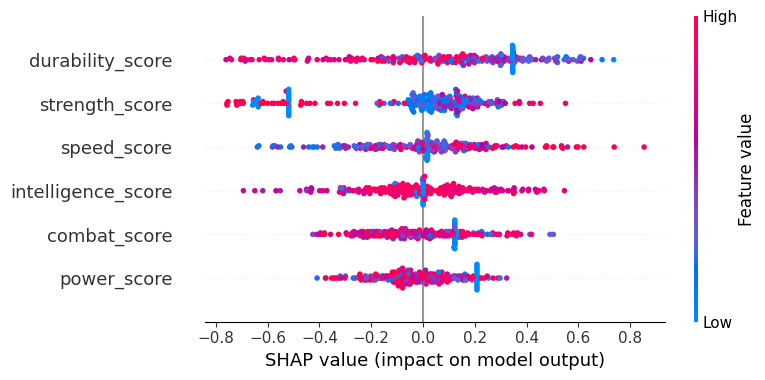

In [73]:
#### Código aquí ####

# Crear explainer para el modelo LightGBM
explainer = shap.TreeExplainer(lgbm_interp)

# Calcular SHAP values sobre test numérico
shap_values = explainer.shap_values(X_test_num)

# Índice de la clase "Good"
good_idx = np.where(lgbm_interp.classes_ == "Good")[0][0]

# Extraer SHAP values de la clase "Good"
shap_values_good = shap_values[:, :, good_idx]

# Summary plot para importancia global y dirección del efecto
shap.summary_plot(
    shap_values_good,
    X_test_num,
    feature_names=NUMERICAL_FEATURES,
)

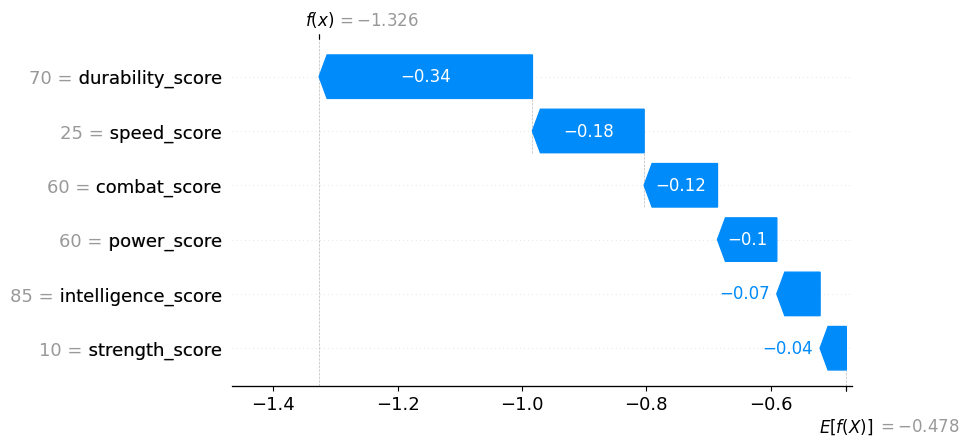

In [ ]:
# Waterfall plot para una instancia cualquiera
idx = 0  # (la primera)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_good[idx],
        base_values=explainer.expected_value[good_idx],
        data=X_test_num.iloc[idx],
        feature_names=NUMERICAL_FEATURES,
    )
)

In [ ]:
X_test.iloc[0]

name                                                  The Shocker (MCU)
real_name                                                Herman Schultz
full_name                                                           NaN
overall_score                                                         7
history_text          Herman Schultz is a former salvage worker who ...
                                            ...                        
has_super_speed                                                     0.0
has_durability                                                      0.0
has_stamina                                                         0.0
has_agility                                                         1.0
has_super_strength                                                  1.0
Name: 1303, Length: 80, dtype: object

In [92]:
X_test.iloc[0]["history_text"]

"Herman Schultz is a former salvage worker who had become a professional criminal and a member of Adrian Toomes' Crew who had sold Chitauri and Ultron based weaponry created by the Tinkerer. Following Toomes murdering Jackson Brice, who had used his modified gauntlet occasionally under the alias of Shocker, Toomes had passed the gauntlet down onto Schultz and appointed him as the new Shocker. With his new title and power of the gauntlet, Shocker still continued to help Toomes with fighting against Spider-Man's ongoing attempts to bring an end to all of the black market arms deals, which resulted in the Shocker being defeated during a fight and arrested."

### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**

1- La principal diferencia es que la Permutation Feature Importance (PFI) entrega una medida de importancia global, mientras que los valores SHAP pueden proporcionar tanto interpretaciones globales como locales. PFI evalúa cuánto disminuye el rendimiento del modelo cuando se permuta una característica, midiendo así su contribución promedio al desempeño general del modelo.

Por otro lado, los valores SHAP cuantifican la contribución de cada característica a una predicción específica. Esto permite entender no solo qué variables son importantes, sino también cómo influyen en cada observación y en qué dirección lo hacen. Además, mediante gráficos como el `summary_plot`, es posible obtener una visión global de estas contribuciones.

Por ejemplo, en el gráfico se observa que variables como `durability_score`, `strength_score` y `speed_score` presentan los mayores valores absolutos de SHAP, por lo que tienen una influencia importante en las predicciones del modelo. También puede apreciarse la dirección del efecto: para algunas variables, valores altos (puntos rojos) tienden a empujar la predicción hacia la clase `Good` (SHAP positivo), mientras que para otras pueden tener el efecto contrario. Esta información no puede obtenerse directamente con PFI, ya que PFI solo indica cuánto importa una variable, pero no cómo influye sobre las predicciones.

En resumen, PFI responde qué tan importante es una variable para el modelo en promedio, mientras que SHAP explica cómo, cuánto y en qué dirección contribuye cada variable a las predicciones individuales y globales del modelo.

2- Según el `waterfall_plot`, las características que más empujaron la predicción hacia la clase predicha fueron `durability_score` (-0.34) y `speed_score` (-0.18), seguidas por `combat_score` (-0.12) y `power_score` (-0.10). Todas las contribuciones son negativas, lo que indica que estas características desplazaron la predicción desde el valor base `E[f(X)] = -0.478` hasta el valor final `f(x) = -1.326`, reforzando la decisión del modelo hacia una clase distinta de `Good`.

La instancia analizada corresponde a **The Shocker (MCU)**, también conocido como **Herman Schultz**. En esta observación, el personaje presenta una velocidad relativamente baja (`speed_score = 25`), una fuerza baja (`strength_score = 10`) y valores moderados de combate, poder y durabilidad. Por ello, el modelo interpreta que estas características no corresponden al perfil que normalmente asocia con personajes de alineación positiva.

La explicación es consistente con la historia del personaje. Según su descripción, Herman Schultz era un trabajador de salvamento que se convirtió en criminal profesional y miembro de la organización de Adrian Toomes (Vulture), participando en la venta ilegal de armamento basado en tecnología Chitauri y de Ultron. Tras asumir el rol de **Shocker**, utilizó sus guanteletes modificados para enfrentarse a Spider-Man y colaborar en actividades criminales, hasta ser finalmente derrotado y arrestado. Dado que la historia lo presenta explícitamente como un antagonista involucrado en delitos y enfrentamientos contra un héroe, resulta razonable que el modelo descarte la clase `Good`. Además, el hecho de que sus habilidades físicas no sean especialmente destacadas refuerza la contribución negativa observada en variables como velocidad, combate, poder y durabilidad, haciendo que la explicación SHAP sea coherente tanto con sus atributos como con su rol narrativo dentro del universo Marvel.

In [ ]:
# Escribe aquí la respuesta

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [82]:
df_comics_no_label.loc[df_comics_no_label["name"].str.contains("Bat-Cow", case=False, na=False)]

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength


In [78]:
df_comics_no_label.loc[df_comics_no_label["name"].str.contains("BatCow", case=False, na=False)]

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
122,Batcow,NaN,NaN,3,Bat-Cow was originally a cow that was found by...,NaN,70,10,25,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
122,Batcow,NaN,NaN,3,Bat-Cow was originally a cow that was found by...,NaN,70,10,25,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#### Código aquí ####

# Eliminar filas sin historia (se eliminan duplicados por las consultas anteriores)
df_pred = df_comics_no_label.dropna(subset=["history_text"]).copy().drop_duplicates()

# Predecir alineación
df_pred["alignment_pred"] = pipe_lgbm_opt.predict(df_pred)

# Mostrar personajes de interés
df_pred.loc[df_pred["name"].isin(["Vergil", "Gorilla Girl", "Batcow"]), ["name", "alignment_pred"]]

,name,alignment_pred
122,Batcow,Good
529,Gorilla Girl,Good
1368,Vergil,Good


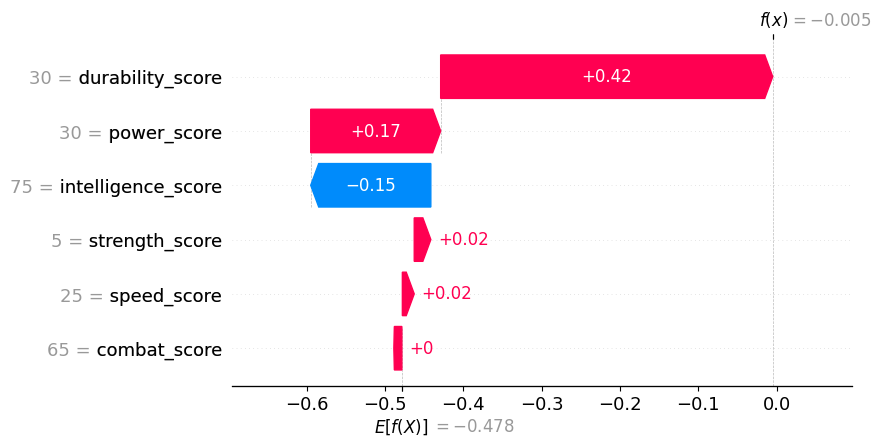

In [83]:
# Waterfall plot para Batcow
idx = 122

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_good[idx],
        base_values=explainer.expected_value[good_idx],
        data=X_test_num.iloc[idx],
        feature_names=NUMERICAL_FEATURES,
    )
)

In [90]:
df_comics_no_label.loc[df_comics_no_label["name"].isin(["Vergil", "Gorilla Girl", "Batcow"]), "history_text"].tolist()

['Bat-Cow was originally a cow that was found by Robin during an investigation on a slaughterhouse, which the cow was sent to. Robin wanted to keep the cow and named it Bat-Cow. Batman decided they would keep the cow. During a later investigation, Batman discovered it had mind-controlling radiation inside of it, leading him to attempt to get rid of the cow. Robin, however would not allow him to hurt the cow. After the events of Robin\'s death, Bat-Cow and Robin\'s dog felt a great loss in morale. Alfred Pennyworth and Nightwing had to take care of the cow. Later after Nightwing\'s disappearance, Alfred was the only caretaker of Bat-Cow. Bat-Cow, complete with cape, spent time on a Wayne Enterprises-owned dairy farm. It was there the cow encountered the cosmic-powered "Forever People." One of them seemed to gain guidance from Bat-Cow\'s actions, namely when Bat-Cow gave one of the Forever People a scarecrow\'s hat. Bat-Cow formed a friendship with Titus, a dog and household cat.',
 'A c

### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

> **Respuesta:**

1- En general, las predicciones obtenidas parecen razonables. **Bat-Cow** fue clasificado como `Good`, lo que es consistente con su historia. Según la descripción disponible, Bat-Cow es una vaca rescatada por Robin durante una investigación y posteriormente adoptada por la Bat-Familia. A lo largo de sus apariciones mantiene una relación cercana con personajes heroicos como Batman, Robin, Nightwing y Alfred, además de ser retratada como una figura amistosa y querida. Aunque no posee habilidades especiales relevantes, su contexto narrativo está claramente asociado a personajes de alineación positiva.

La predicción de **Gorilla Girl** como `Good` también resulta coherente. Su historia indica que, tras ser liberada del control del villano Moondark junto a otros artistas de carnaval, participó en un equipo de superhéroes llamado *The Freaks*. En su única misión conocida, ayudó a rescatar a un médico de un secuestro, lo que corresponde claramente a acciones heroicas y justifica una alineación positiva.

La predicción más discutible es la de **Vergil**. Su descripción lo presenta como uno de los principales antagonistas de la saga *Devil May Cry* y rival de Dante, además de ser conocido bajo la identidad de Nelo Angelo. Aunque el texto menciona principalmente sus relaciones familiares y su papel dentro de la historia, también lo identifica explícitamente como antagonista. Por ello, una clasificación como `Good` no parece tan consistente con el personaje y podría deberse a que el modelo capturó palabras asociadas a protagonistas o vínculos familiares importantes, sin reflejar completamente su rol de villano.

En conjunto, las predicciones para **Bat-Cow** y **Gorilla Girl** son coherentes con la información disponible en sus historias, mientras que la de **Vergil** parece ser un error razonable del modelo, probablemente causado por la complejidad y ambigüedad de su descripción textual.

2- Según el `waterfall_plot` de **Bat-Cow**, las características numéricas que más influyeron en la predicción fueron `durability_score` (+0.42) y `power_score` (+0.17), ya que son las que generan los mayores aportes positivos desde el valor base `E[f(X)] = -0.478` hasta el valor final `f(x) = -0.005`. En contraste, `intelligence_score` tuvo una contribución negativa (-0.15), mientras que `strength_score` y `speed_score` tuvieron efectos positivos muy pequeños.

Estos resultados son parcialmente consistentes con la predicción obtenida de `Good`. Por una parte, el modelo considera que la durabilidad y el poder aportan evidencia a favor de una alineación positiva. Sin embargo, desde el punto de vista narrativo, Bat-Cow no es un personaje definido por sus habilidades físicas, sino por su estrecha relación con Batman, Robin y el resto de la Bat-Familia. Su historia lo presenta como una mascota amigable y asociada constantemente a héroes, lo que naturalmente sugiere una alineación positiva.

Por ello, aunque las variables numéricas ayudan a empujar la predicción hacia `Good`, la justificación más convincente proviene del contexto descrito en su historia. Esto es consistente con las observaciones realizadas en la sección de interpretabilidad: los atributos numéricos entregan parte de la explicación, pero en este problema la información textual parece ser mucho más relevante para capturar correctamente la alineación de personajes como Bat-Cow.

In [ ]:
# Escribe aquí la respuesta

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>